In [18]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

from scipy.stats import chisquare


In [19]:
Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module',
    'ESP Vibration Module'
    # 'ESP Vibration X',
    # 'ESP Vibration Y',
    #'ESP Power',
    #"Well_down"
    ]

In [20]:
totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

pumpList = totalData["Well Run"].unique()

totalData["Choke Closed"] = 1-totalData["Choke Opening"]
totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)


/tmp/ipykernel_161675/3036563576.py:1: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


In [21]:
seeds = np.random.randint(low=19971215,high=20210505,size=30)

seeds.shape

(30,)

In [22]:
n = 3

mainSeed = 971215
np.random.seed(mainSeed)

seeds = np.random.randint(low=19971215,high=20210505,size=30)

medianList = np.array([]).astype(int)

for seed in seeds:
    X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

    radiusData = totalData["Radius"].loc[totalData["Well_down"]==0]


    modelGMMradius = li.GaussianMixtureFit(radiusData,n,seed=mainSeed)
    
    modelRadius = hmm.GaussianHMM(
        n_components=n,
        random_state=mainSeed,
        covariance_type="full",
        init_params="st",
        #params="st"
        )

    modelRadius.means_ = modelGMMradius.means_
    modelRadius.covars__ = modelGMMradius.covariances_

    modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)


    li.PostProcessing(modelRadius, totalData, modelData,"Radius", "State Radius", totalLength)

    totalData["State Radius"] = totalData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))


    medianList_G = np.array([])

    for pump in pumpList:
        pumpData = totalData.loc[(totalData["Well Run"]==pump) & (totalData["Well_down"]==0) ]#.copy()
        last = pumpData.shape[0]
        pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
        medianList_G = np.append(medianList_G,pumpMedianR)


    medianList = np.concatenate((medianList, medianList_G))


GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1806435.123855277 BIC: 1806598.2219071817
GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1832246.7481434073 BIC: 1832409.846195312
GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1851362.0122691207 BIC: 1851525.1103210254
GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1828740.3088925015 BIC: 1828903.4069444062
GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1844421.9206123748 BIC: 1844585.0186642795
GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1838559.71417762 BIC: 1838722.8122295246
GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1825050.7540276563 BIC: 1825213.852079561
GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1851973.171855584 BIC: 1852136.2699074887
GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1876380.158303172 BIC: 1876543.2563550768
GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842
AIC: 1817401.3649064885 BIC: 181756

In [31]:
saveA = np.array(medianList).T
pd.DataFrame(saveA,columns=["R"]).to_csv("saveA_direto.csv")

In [32]:
saveA = pd.read_csv("saveA_direto.csv")

In [33]:
medianList = saveA["R"].to_numpy()

In [34]:
cmap = plt.get_cmap('Oranges', 4)

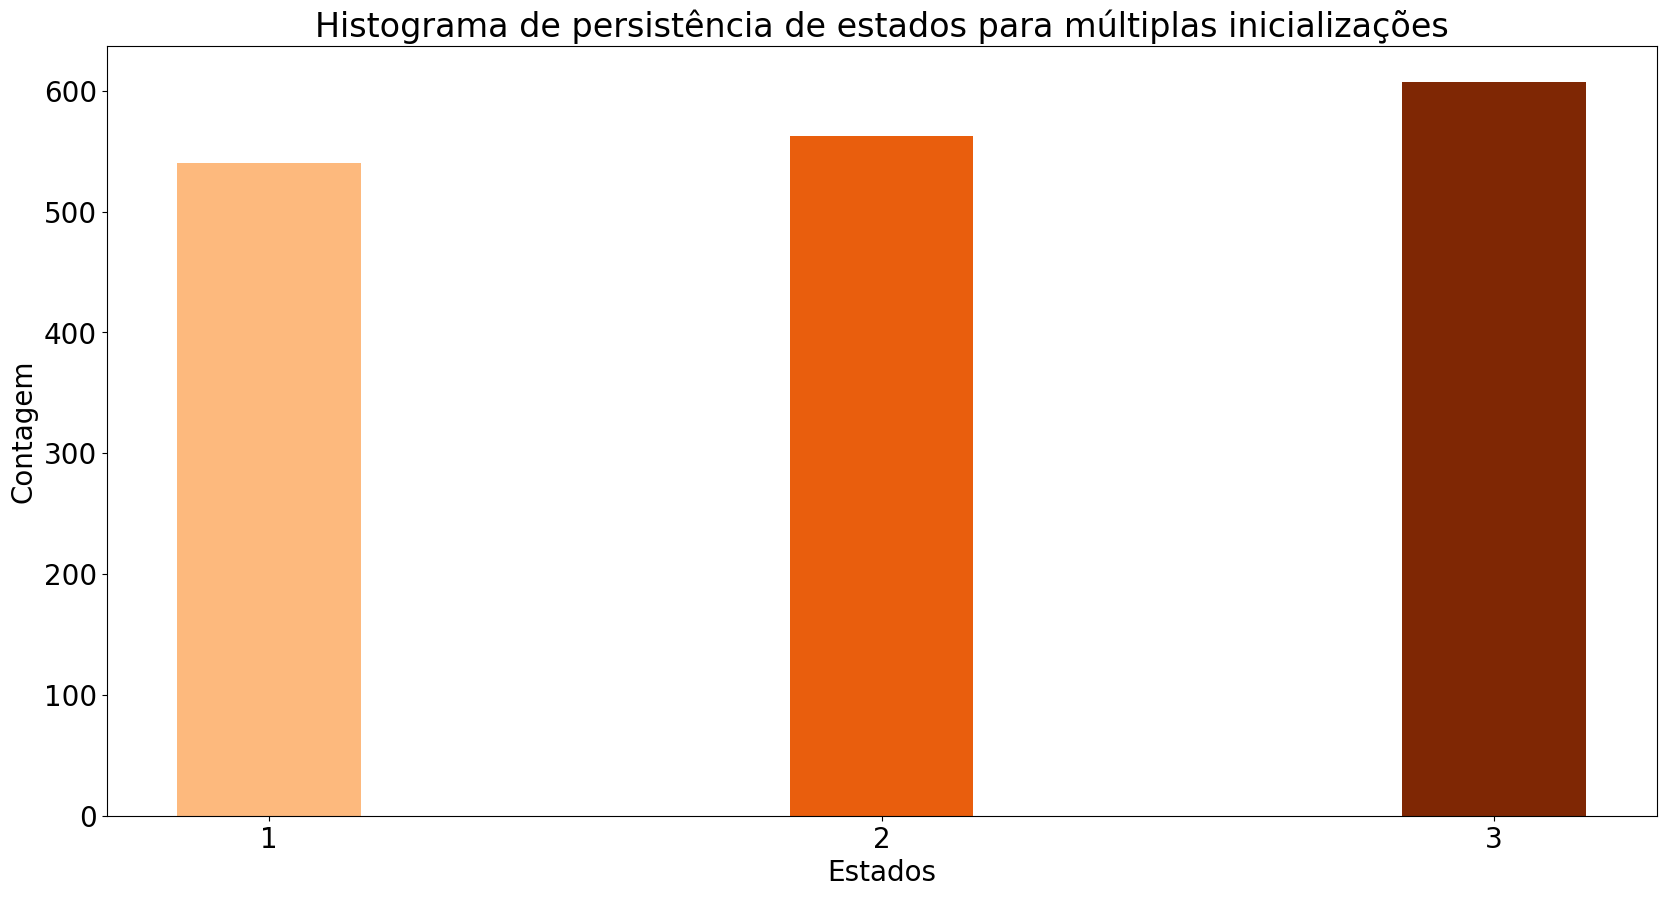

In [35]:

plt.figure(figsize=(20,10))

plt.rcParams["font.size"] = 20
states,counts = np.unique(medianList,return_counts=True)

plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
plt.xticks(states,np.int64(states))
# plt.ylabel("Counts")
# plt.xlabel("States")
# plt.title("Radius Persistence Histogram - Multiple Seeds")
# plt.savefig("../imagens_gerais/multiple_seeds_radius_histogram.jpg")

plt.ylabel("Contagem")
plt.xlabel("Estados")
plt.title("Histograma de persistência de estados para múltiplas inicializações")
plt.savefig("../imagens_gerais/multiple_seeds_radius_histogram_pt.jpg")

In [28]:
# plt.figure(figsize=(7,5))
# plt.hist(medianListV)
# plt.title("Histograma da média de Persistência de Estados - Módulo da Vibração")

In [29]:
# Contagens das classes ao longo das inicializações
observed_counts = np.array([counts[0],counts[1],counts[2]]) # Substituir pelos valores reais
expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")

Estatística qui-quadrado: 4.0667, p-valor: 0.1309
Não há evidências suficientes para afirmar que C ocorre mais que o esperado.
